In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("dataset/spam.csv")

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (5572, 2)


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB
None


In [6]:
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [7]:
spam_count = (df["label"] == "spam").sum()
ham_count = (df["label"] == "ham").sum()

print("Total Messages    :", len(df))
print("Spam Messages     :", spam_count)
print("Not Spam Messages :", ham_count)

Total Messages    : 5572
Spam Messages     : 747
Not Spam Messages : 4825


In [8]:
total = len(df)

spam_percentage = (spam_count / total) * 100
ham_percentage = (ham_count / total) * 100

print("Spam Percentage     :", round(spam_percentage, 2), "%")
print("Not Spam Percentage :", round(ham_percentage, 2), "%")

Spam Percentage     : 13.41 %
Not Spam Percentage : 86.59 %


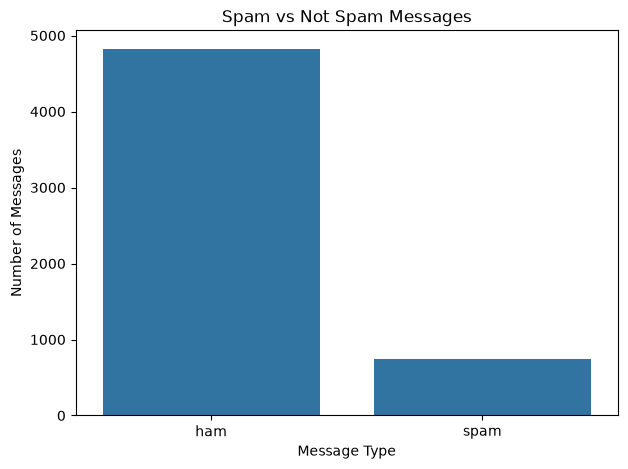

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="label")

plt.title("Spam vs Not Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [10]:
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [11]:
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [12]:
X = df["message"]
y = df["label_num"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [14]:
print("Training Messages:", len(X_train))
print("Testing Messages :", len(X_test))

Training Messages: 4457
Testing Messages : 1115


In [15]:
print("Total Messages:", len(df))
print("Spam Messages:", spam_count)
print("Not Spam Messages:", ham_count)
print("Training Messages:", len(X_train))
print("Testing Messages:", len(X_test))

Total Messages: 5572
Spam Messages: 747
Not Spam Messages: 4825
Training Messages: 4457
Testing Messages: 1115


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [17]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

In [18]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [19]:
X_test_tfidf = vectorizer.transform(X_test)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

In [23]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [24]:
X_test_tfidf = vectorizer.transform(X_test)

In [25]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape :", X_test_tfidf.shape)

Training shape: (4457, 7403)
Testing shape : (1115, 7403)


In [26]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Naïve Bayes model trained successfully!")

Naïve Bayes model trained successfully!


In [27]:
y_pred = model.predict(X_test_tfidf)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.9704035874439462
Accuracy Percentage: 97.04 %


In [29]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=["Not Spam", "Spam"]
)

print(report)

              precision    recall  f1-score   support

    Not Spam       0.97      1.00      0.98       966
        Spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[966   0]
 [ 33 116]]


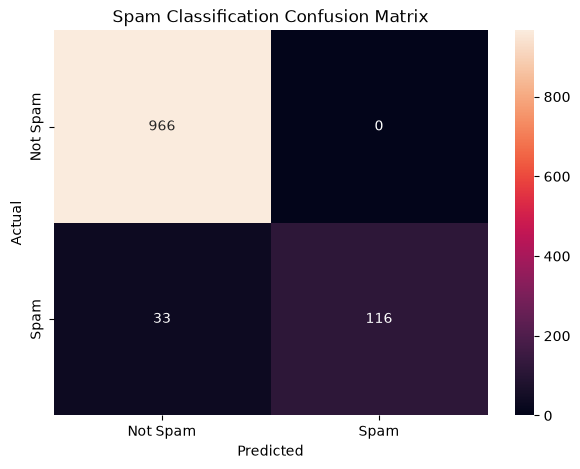

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Spam", "Spam"],
    yticklabels=["Not Spam", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Spam Classification Confusion Matrix")

plt.show()

In [32]:
def predict_message(message):
    message_tfidf = vectorizer.transform([message])
    prediction = model.predict(message_tfidf)[0]

    if prediction == 1:
        return "🚨 SPAM"
    else:
        return "✅ NOT SPAM"

In [33]:
message = "Congratulations! You have won a free cash prize!"
print(predict_message(message))

🚨 SPAM


In [34]:
message = "Hi, are you coming to college tomorrow?"
print(predict_message(message))

✅ NOT SPAM


In [35]:
message = "URGENT! Claim your free reward now!"
print(predict_message(message))

🚨 SPAM


In [36]:
message = input("Enter your message: ")

result = predict_message(message)

print("\nPrediction:", result)

Enter your message:  You have won a free lottery prize



Prediction: 🚨 SPAM


In [37]:
import joblib

In [38]:
joblib.dump(model, "model/spam_model.pkl")

['model/spam_model.pkl']

In [39]:
joblib.dump(vectorizer, "model/tfidf_vectorizer.pkl")

['model/tfidf_vectorizer.pkl']